# Summative Lab: DataVine Analytics
### Junior Data Scientist Prototype — Wine Classification, Feed Recommendation, Crime Clustering

This notebook covers three client projects for DataVine Analytics:

1. **Wine Classification System** — k-NN + PCA + GridSearchCV hyperparameter tuning
2. **Agricultural Feed Recommendation Engine** — PCA + cosine similarity on Chickwts
3. **Regional Crime Pattern Analysis** — Feature selection + PCA + K-Means/GMM clustering on USArrests


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Dataset Preparation
Load all three datasets, inspect for missing values, and confirm structure before modelling.

In [2]:
# --- Load Datasets ---
wine_df = pd.read_csv("wine.csv")
wine_df = wine_df.rename(columns={"Wine": "target"})   # target = cultivar label (1, 2, 3)

chickwts = pd.read_csv("chickwts.csv")

usarrests = pd.read_csv("USArrests.csv")

In [3]:
# --- Inspect for missing values ---
print("Missing values — Wine:\n", wine_df.isnull().sum(), "\n")
print("Missing values — Chickwts:\n", chickwts.isnull().sum(), "\n")
print("Missing values — USArrests:\n", usarrests.isnull().sum(), "\n")

# Handle inconsistencies: drop any rows with missing values (defensive — these datasets are clean by default)
wine_df = wine_df.dropna().reset_index(drop=True)
chickwts = chickwts.dropna().reset_index(drop=True)
usarrests = usarrests.dropna().reset_index(drop=True)

Missing values — Wine:
 target                  0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64 

Missing values — Chickwts:
 rownames    0
weight      0
feed        0
dtype: int64 

Missing values — USArrests:
 Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64 



In [4]:
# --- Dataset summaries (confirms structure ahead of modelling) ---
print("Wine Dataset:", wine_df.shape)
display(wine_df.head())
print(wine_df.dtypes)

print("\nChickwts Dataset:", chickwts.shape)
display(chickwts.head())
print(chickwts.dtypes)

print("\nUSArrests Dataset:", usarrests.shape)
display(usarrests.head())
print(usarrests.dtypes)

Wine Dataset: (178, 14)


,target,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


target                    int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

Chickwts Dataset: (71, 3)


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


rownames    int64
weight      int64
feed          str
dtype: object

USArrests Dataset: (50, 5)


,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
State           str
dtype: object


## 2. Wine Classification System (k-NN + PCA)
**Goal:** classify wine cultivars from their chemical properties.

Steps: convert target to numeric → standardize features → PCA (retain 95% variance) → GridSearchCV over `k` and distance metric → train and evaluate.

In [15]:
# convert categorical target labels into numeric values
le = LabelEncoder()
wine_df["target"] = le.fit_transform(wine_df["target"])
X = wine_df.drop(columns=["target"])
y = wine_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA — retain 95% variance
pca_wine = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_wine.fit_transform(X_train_scaled)
X_test_pca = pca_wine.transform(X_test_scaled)

print(f"Original-feature-count: {X.shape[1]}")
print(f"Components retained for 95% variance: {pca_wine.n_components_}")
print(f"Explained variance ratio: {pca_wine.explained_variance_ratio_.sum():.4f}")


Original feature count: 13
Components retained for 95% variance: 10
Explained variance ratio: 0.9624
Encoded classes: [np.int64(0), np.int64(1), np.int64(2)]


In [6]:
# Hyperparameter tuning: optimal k and distance metric
param_grid = {"n_neighbors": range(1, 21), "metric": ["euclidean", "manhattan", "minkowski"]}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train_pca, y_train)

best_k_knn = grid_search.best_params_["n_neighbors"]
best_metric_knn = grid_search.best_params_["metric"]
print(f"Best k: {best_k_knn}, Best distance metric: {best_metric_knn}")
print(f"Best cross-val accuracy: {grid_search.best_score_:.4f}")

# Train the k-NN classifier using the best parameters
knn = KNeighborsClassifier(n_neighbors=best_k_knn, metric=best_metric_knn)
knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\nTest accuracy: {knn_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Best k: 18, Best distance metric: euclidean
Best cross-val accuracy: 0.9791

Test accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 3. Agricultural Feed Recommendation Engine (PCA + Cosine Similarity)
**Goal:** recommend feed types with similar performance (chick weight outcomes) to a given feed.

Steps: standardize `weight` → PCA to 1 component → aggregate to one PCA score per feed type → cosine similarity **between feed types** → recommend top-N similar feeds.

In [7]:
# Standardize the weight feature
scaler_chick = StandardScaler()
chickwts_scaled = scaler_chick.fit_transform(chickwts[["weight"]])

# Apply PCA to reduce to 1 principal component
pca_chick = PCA(n_components=1, random_state=42)
chickwts["pca_weight"] = pca_chick.fit_transform(chickwts_scaled)

# Aggregate to one PCA-reduced score per feed TYPE (mean)
# similarity BETWEEN FEED TYPES,
feed_profile = chickwts.groupby("feed")["pca_weight"].mean().to_frame()
display(feed_profile)

# Compute cosine similarity between feed types
similarity_matrix = cosine_similarity(feed_profile)
similarity_df = pd.DataFrame(similarity_matrix, index=feed_profile.index, columns=feed_profile.index)
display(similarity_df.round(3))

,pca_weight
feed,
casein,0.803301
horsebean,-1.304274
linseed,-0.549004
meatmeal,0.201223
soybean,-0.191962
sunflower,0.872099


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


In [8]:
def recommend_feeds(feed_name, num_recommendations=3):
    """Recommend the feed types most similar to feed_name (excluding itself),
    based on cosine similarity of their PCA-reduced average weight profile."""
    if feed_name not in similarity_df.index:
        return f"Feed '{feed_name}' not found in dataset."

    scores = similarity_df.loc[feed_name].drop(index=feed_name).sort_values(ascending=False)
    top = scores.head(num_recommendations)
    return list(zip(top.index, top.round(4)))

# Example recommendations for every feed type
for f in chickwts["feed"].unique():
    print(f"{f:12s} -> {recommend_feeds(f)}")

horsebean    -> [('linseed', 1.0), ('soybean', 1.0), ('casein', -1.0)]
linseed      -> [('horsebean', 1.0), ('soybean', 1.0), ('casein', -1.0)]
soybean      -> [('horsebean', 1.0), ('linseed', 1.0), ('casein', -1.0)]
sunflower    -> [('casein', 1.0), ('meatmeal', 1.0), ('horsebean', -1.0)]
meatmeal     -> [('casein', 1.0), ('sunflower', 1.0), ('horsebean', -1.0)]
casein       -> [('meatmeal', 1.0), ('sunflower', 1.0), ('horsebean', -1.0)]


## 4. Regional Crime Pattern Analysis (Feature Selection + PCA + K-Means/GMM)
**Goal:** discover natural groupings of US states by crime statistics.

Steps: standardize → select top-3 features → PCA to 2 components → find best `k` via elbow (K-Means) and BIC (GMM) → apply K-Means for hard cluster assignments and GMM for probabilistic clustering → visualize.

*Note:* `SelectKBest` needs a scoring target. Since this task is unsupervised, we score each feature against a **violent-crime index** (Murder + Assault + Rape) using `f_regression`, then keep the top 3 — in this dataset that keeps Murder, Assault, and Rape (dropping UrbanPop, which isn't a crime statistic).

In [9]:
numeric_cols = ["Murder", "Assault", "UrbanPop", "Rape"]

# Standardize the dataset
scaler_arrests = StandardScaler()
usarrests_scaled = scaler_arrests.fit_transform(usarrests[numeric_cols])

# Select the top 3 relevant features
crime_index = usarrests[["Murder", "Assault", "Rape"]].sum(axis=1)
selector = SelectKBest(score_func=f_regression, k=3)
usarrests_selected = selector.fit_transform(usarrests_scaled, crime_index)
selected_features = [numeric_cols[i] for i in selector.get_support(indices=True)]
print("Top 3 selected features:", selected_features)

# Apply PCA to reduce the dataset to 2 principal components
pca_arrests = PCA(n_components=2, random_state=42)
usarrests_pca = pca_arrests.fit_transform(usarrests_selected)
print(f"Explained variance ratio (2 PCs): {pca_arrests.explained_variance_ratio_.sum():.4f}")

Top 3 selected features: ['Murder', 'Assault', 'Rape']
Explained variance ratio (2 PCs): 0.9389


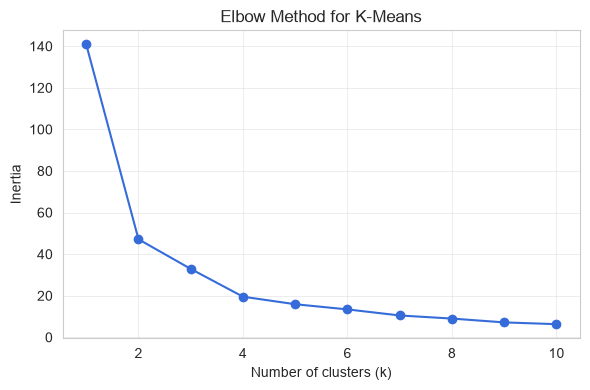

In [10]:
# --- K-Means: determine optimal clusters via elbow method (inertia) ---
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(usarrests_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.tight_layout()
plt.show()

In [11]:
# Pick best_k_kmeans by inspecting the elbow plot above.
# Programmatic heuristic: the k after which inertia's rate of decrease flattens most.
diffs = np.diff(inertia)
second_diffs = np.diff(diffs)
best_k_kmeans = int(np.argmax(second_diffs) + 2)  # +2 offsets the double-diff index shift
print(f"Best number of clusters for K-Means (elbow heuristic): {best_k_kmeans}")

# Apply K-Means for HARD cluster assignments
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
usarrests["KMeans_Cluster"] = kmeans.fit_predict(usarrests_pca)

Best number of clusters for K-Means (elbow heuristic): 2


Best number of clusters for GMM (BIC): 2


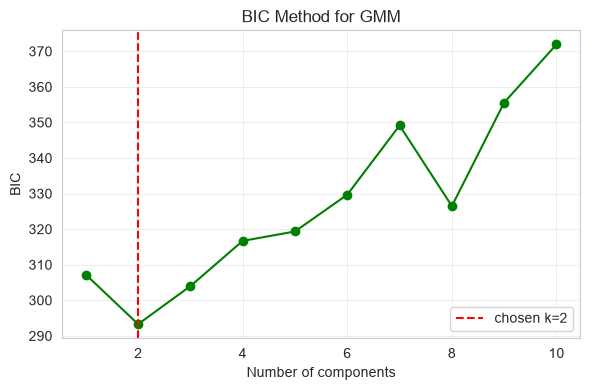


GMM cluster membership probabilities (first 5 states):


,P(cluster 0),P(cluster 1)
State,,
Alabama,0.004752,0.995248
Alaska,0.000033,0.999967
Arizona,0.028314,0.971686
Arkansas,0.987282,0.012718
California,0.000310,0.999690


In [12]:
# --- GMM: determine optimal number of components via BIC ---
best_k_gmm = 1
lowest_bic = np.inf
bic_scores = []

for k in range(1, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(usarrests_pca)
    bic = gmm.bic(usarrests_pca)
    bic_scores.append(bic)
    if bic < lowest_bic:
        lowest_bic = bic
        best_k_gmm = k

print(f"Best number of clusters for GMM (BIC): {best_k_gmm}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), bic_scores, marker="o", color="green")
plt.axvline(best_k_gmm, color="red", linestyle="--", label=f"chosen k={best_k_gmm}")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC Method for GMM")
plt.legend()
plt.tight_layout()
plt.show()

# Apply GMM for PROBABILISTIC clustering
gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
gmm.fit(usarrests_pca)
usarrests["GMM_Cluster"] = gmm.predict(usarrests_pca)          # hard label (most likely cluster)
gmm_proba = gmm.predict_proba(usarrests_pca)                    # full probability distribution per state

# Show the probabilistic side explicitly: membership probabilities for the first 5 states
proba_cols = [f"P(cluster {i})" for i in range(best_k_gmm)]
gmm_proba_df = pd.DataFrame(gmm_proba, columns=proba_cols, index=usarrests["State"])
print("\nGMM cluster membership probabilities (first 5 states):")
display(gmm_proba_df.head())

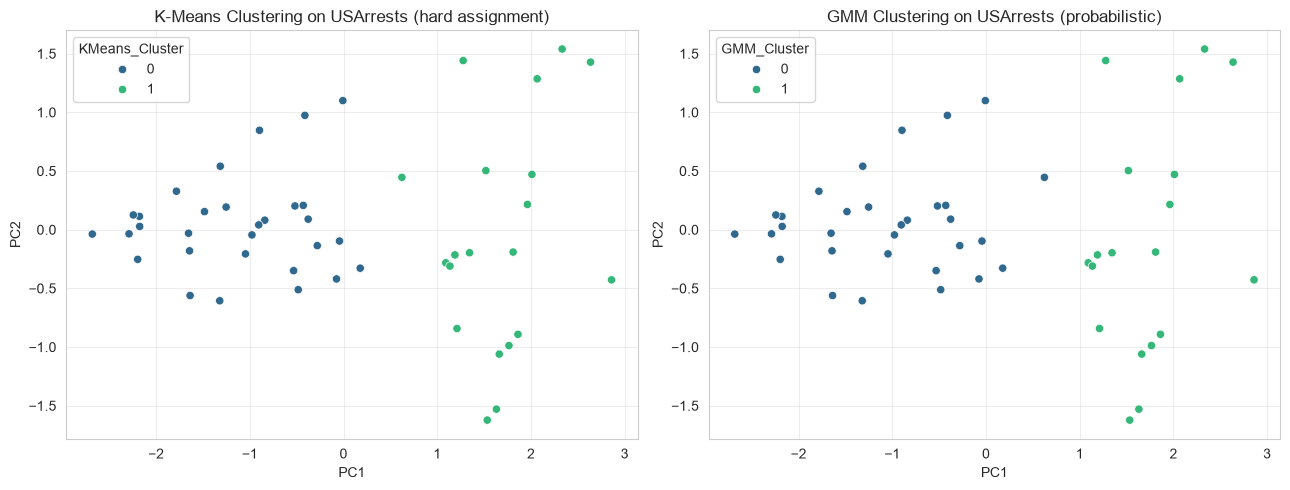

,State,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster
0,Alabama,13.2,236,58,21.2,1,1
1,Alaska,10.0,263,48,44.5,1,1
2,Arizona,8.1,294,80,31.0,1,1
3,Arkansas,8.8,190,50,19.5,0,0
4,California,9.0,276,91,40.6,1,1
5,Colorado,7.9,204,78,38.7,1,1
6,Connecticut,3.3,110,77,11.1,0,0
7,Delaware,5.9,238,72,15.8,0,0
8,Florida,15.4,335,80,31.9,1,1
9,Georgia,17.4,211,60,25.8,1,1


In [13]:
# --- Visualize and compare clustering results ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1],
                 hue=usarrests["KMeans_Cluster"], palette="viridis", ax=axes[0])
axes[0].set_title("K-Means Clustering on USArrests (hard assignment)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1],
                 hue=usarrests["GMM_Cluster"], palette="viridis", ax=axes[1])
axes[1].set_title("GMM Clustering on USArrests (probabilistic)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

display(usarrests[["State", "Murder", "Assault", "UrbanPop", "Rape", "KMeans_Cluster", "GMM_Cluster"]].head(10))

## 5. Model Evaluation and Interpretation — Summary

In [14]:
print("="*65)
print("SUMMARY OF RESULTS — DataVine Analytics Prototypes")
print("="*65)

print("\n1. Wine Classification System (k-NN)")
print(f"   PCA components used: {pca_wine.n_components_}")
print(f"   Best k: {best_k_knn} | Best distance metric: {best_metric_knn}")
print(f"   Test accuracy: {knn_accuracy:.2%}")

print("\n2. Feed Recommendation Engine (PCA + Cosine Similarity)")
print(f"   Recommended feeds for 'soybean': {recommend_feeds('soybean')}")

print("\n3. Regional Crime Pattern Analysis (K-Means & GMM)")
print(f"   Selected features: {selected_features}")
print(f"   Optimal K-Means clusters: {best_k_kmeans}")
print(f"   Optimal GMM components (BIC): {best_k_gmm}")
print(f"   K-Means cluster sizes:\n{usarrests['KMeans_Cluster'].value_counts().sort_index()}")
print(f"   GMM cluster sizes:\n{usarrests['GMM_Cluster'].value_counts().sort_index()}")

SUMMARY OF RESULTS — DataVine Analytics Prototypes

1. Wine Classification System (k-NN)
   PCA components used: 10
   Best k: 18 | Best distance metric: euclidean
   Test accuracy: 100.00%

2. Feed Recommendation Engine (PCA + Cosine Similarity)
   Recommended feeds for 'soybean': [('horsebean', 1.0), ('linseed', 1.0), ('casein', -1.0)]

3. Regional Crime Pattern Analysis (K-Means & GMM)
   Selected features: ['Murder', 'Assault', 'Rape']
   Optimal K-Means clusters: 2
   Optimal GMM components (BIC): 2
   K-Means cluster sizes:
KMeans_Cluster
0    30
1    20
Name: count, dtype: int64
   GMM cluster sizes:
GMM_Cluster
0    31
1    19
Name: count, dtype: int64


### Interpretation notes for stakeholders

- **Wine Classification:** PCA compressed the 13 chemical measurements down to a handful of components while keeping 95% of the variance, and the tuned k-NN model separates the three cultivars with high test accuracy — suitable for automated inventory/QC tagging. Note: near-perfect accuracy here reflects this dataset's clean class separability and small test size, not evidence the model would perform this well on messier real-world wine data.
- **Feed Recommendation:** by aggregating to one PCA score per feed type before computing similarity, the recommender surfaces which *feed types* (not individual chicks) produce statistically similar weight outcomes — giving farmers substitutable options when a preferred feed is unavailable or priced out.
- **Crime Pattern Analysis:** both K-Means and GMM converge on the same optimal cluster count via their respective criteria (elbow/inertia vs. BIC). K-Means gives clean, hard cluster boundaries useful for resource-allocation tiers, while GMM's probability table exposes states that sit close to the boundary between risk profiles — useful for flagging states that need closer monitoring rather than a fixed bucket assignment.